# Implementing gradient decsent in Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate a single dataset 

( $y = 2x + 1$ with noise)

### `np.linspace`

Return evenly spaced number in a given interval

### `np.random.normal`

Draw random samples from a normal (Gaussian) distribution.

`np.random.normal(loc=0.0, scale=1.0(standard deviation), size=None)`

In [2]:
np.random.seed(42)
X = np.linspace(0, 10, 50) # 50 evenly spaced points between 0 and 10
true_m, true_c = 2, 1
y = true_m * X + true_c + np.random.normal(0, 2, X.shape) # Add some noise.

## Initialize Parameters
(for slope $m$ and intercept $c$)

In [3]:
m, c = 0.0, 0.0
learning_rate=0.026
iterations=100

#Store loss for plotting
loss_history = []

In [4]:
len(X) # 50 data points

50

In [5]:
X.shape

(50,)

In [6]:
X

array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

In [7]:
y

array([ 1.99342831,  1.13163466,  3.11170361,  5.27054951,  2.16434631,
        2.57254241,  6.60740522,  5.39201232,  3.32635735,  5.75858947,
        4.15479727,  4.55833641,  6.38188373,  2.47956196,  3.26445005,
        5.99787392,  5.50495   ,  8.56727018,  6.53089062,  5.93049464,
       12.09456284,  9.11987597, 10.11464825,  7.53825873,  9.70715292,
       11.42592681,  9.31025774, 12.7718042 , 11.22729405, 12.25334719,
       12.04148473, 17.35761759, 14.03423004, 12.3539659 , 16.52264084,
       12.84402699, 16.11160474, 12.18270057, 13.85383198, 17.31208982,
       18.80346377, 18.07743044, 17.91156058, 17.94881302, 16.00213969,
       17.92765852, 18.85423266, 22.29791792, 21.27907331, 17.47391969])

## Gradient Descent

### Mean Square Error / 均方误差:
$$
L(m,c)
= \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
= \frac{1}{n}\sum_{i=1}^{n}(y_i-mx_i-c)^2
$$

### Partial Derivative on $m$:

Consider the squared residual of each point:
$
(y_i-mx_i-c)^2
$

Let $ u_i = y_i-mx_i-c $

According to Chain Rule: $
\frac{\partial (u_i^2)}{\partial m}
= 2u_i\frac{\partial u_i}{\partial m}$

Apply partial derivative on $m$

$
\frac{\partial u_i}{\partial m}
= \frac{\partial y_i}{\partial m} - \frac{\partial (mx_i)}{\partial m} - \frac{\partial c}{\partial m}
= 0-x_i-0
= -x_i
$

Thus:

$
\frac{\partial}{\partial m}(y_i-mx_i-c)^2
= 2(y_i-mx_i-c)(-x_i)
$

Sum up all samples and then divide by sample number:

$
\begin{aligned}
\frac{\partial L}{\partial m}
&= \frac{1}{n}\sum_{i=1}^{n}
   \frac{\partial}{\partial m}(y_i-mx_i-c)^2 \\
&= \frac{1}{n}\sum_{i=1}^{n}
   2(y_i-mx_i-c)(-x_i) \\
&= -\frac{2}{n}\sum_{i=1}^{n}
   x_i(y_i-mx_i-c) \\
&= -\frac{2}{n}\sum_{i=1}^{n}
   x_i(y_i-\hat{y}_i)
\end{aligned}
$

Finally:

$$
\boxed{
\frac{\partial L}{\partial m}
= -\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-\hat{y}_i)
}
$$

Alternatively, $x_i$ Comes from:

$
\frac{\partial \hat{y}_i}{\partial m}
= \frac{\partial (mx_i+c)}{\partial m}
= x_i
$

### Partial Derivative on $c$:

Apply Partial Derivative on $c$：

$
\frac{\partial u_i}{\partial c}
= \frac{\partial}{\partial c}(y_i-mx_i-c)
= 0-0-1
= -1
$

According to Chain Rule:

$
\frac{\partial}{\partial c}(y_i-mx_i-c)^2
= 2(y_i-mx_i-c)(-1)
$

Thus:

$
\begin{aligned}
\frac{\partial L}{\partial c}
&= \frac{1}{n}\sum_{i=1}^{n}
   \frac{\partial}{\partial c}(y_i-mx_i-c)^2 \\
&= \frac{1}{n}\sum_{i=1}^{n}
   2(y_i-mx_i-c)(-1) \\
&= -\frac{2}{n}\sum_{i=1}^{n}
   (y_i-mx_i-c) \\
&= -\frac{2}{n}\sum_{i=1}^{n}
   (y_i-\hat{y}_i)
\end{aligned}
$

Finally:

$$
\boxed{
\frac{\partial L}{\partial c}
= -\frac{2}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)
}
$$

In [8]:
for i in range(iterations):
    #Predicted y values
    y_pred = m * X + c

    #Compute gradients
    m_grad = (-2/len(X)) * np.sum(X*(y-y_pred))
    c_grad = (-2/len(X)) * np.sum(y-y_pred)

    #Update parameters
    m = m - learning_rate*m_grad
    c = c - learning_rate*c_grad

    #Compute loss(Mean Square Error)
    loss = np.mean((y-y_pred)**2)
    loss_history.append(loss)

    #Print updates every 10 iterations
    if (i+1) % 10 == 0:
        print(f"Iteration {i+1}: Loss = {loss:.4f}, m = {m:.4f}, c = {c:.4f}")

Iteration 10: Loss = 5.4744, m = 1.8027, c = 0.3744
Iteration 20: Loss = 3.4259, m = 1.9613, c = 0.4898
Iteration 30: Loss = 3.3830, m = 1.9658, c = 0.5709
Iteration 40: Loss = 3.3638, m = 1.9570, c = 0.6400
Iteration 50: Loss = 3.3491, m = 1.9481, c = 0.7005
Iteration 60: Loss = 3.3379, m = 1.9402, c = 0.7534
Iteration 70: Loss = 3.3292, m = 1.9333, c = 0.7998
Iteration 80: Loss = 3.3226, m = 1.9272, c = 0.8405
Iteration 90: Loss = 3.3175, m = 1.9219, c = 0.8761
Iteration 100: Loss = 3.3136, m = 1.9172, c = 0.9073


## Representing the result

Final parameters: m = 1.9172, c = 0.91


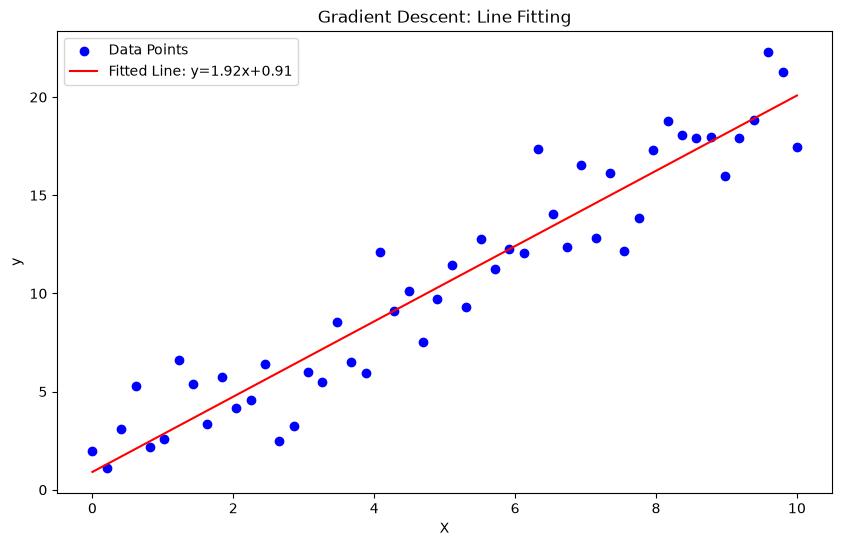

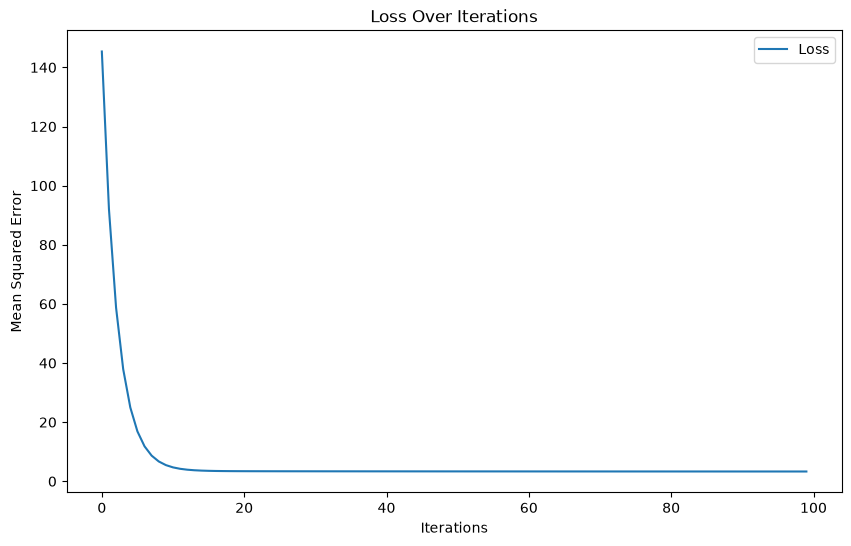

In [9]:
print(f"Final parameters: m = {m:.4f}, c = {c:.2f}")

#Plot the dataset and the fitted line
plt.figure(figsize=(10,6))
plt.scatter(X, y, label="Data Points", color="blue")
plt.plot(X, m*X+c, label=f"Fitted Line: y={m:.2f}x+{c:.2f}", color="red")
plt.title("Gradient Descent: Line Fitting")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

#Plot loss history
plt.figure(figsize=(10,6))
plt.plot(range(iterations), loss_history, label="Loss")
plt.title("Loss Over Iterations")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()